To understand the complete workflow of how Interrupts in LangGraph work, we will build an approval workflow. This pattern allows a state machine to "pause" its execution mid-node, persist its state to a database, and wait for external input before resuming exactly where it left off.

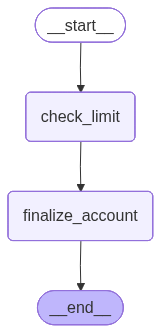

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

# 1. State Definition
class State(TypedDict):
    request_amount: int
    status: str
    manager_approved: bool

# 2. Nodes
def check_limit(state: State):
    print("--- Checking Request Amount ---")
    if state["request_amount"] > 5000:
        # The graph pauses here and returns the string to the caller
        is_approved = interrupt("Request exceeds $5k. Approve? (True/False)")
        return {"manager_approved": is_approved, "status": "Reviewed"}
    
    return {"manager_approved": True, "status": "Auto-Approved"}

def finalize_account(state: State):
    print("--- Finalizing Account ---")
    decision = "Approved" if state["manager_approved"] else "Denied"
    return {"status": f"Final Decision: {decision}"}

# 3. Graph Construction
builder = StateGraph(State)
builder.add_node("check_limit", check_limit)
builder.add_node("finalize_account", finalize_account)

builder.add_edge(START, "check_limit")
builder.add_edge("check_limit", "finalize_account")
builder.add_edge("finalize_account", END)

# Checkpointer is required for interrupts to persist state
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)
graph


In [16]:
# The Demo Execution
config = {"configurable": {"thread_id": "demo-123"}}

# --- INITIAL RUN ---
print("Running initial request for $10,000...")
initial_result = graph.invoke({"request_amount": 10000}, config)

# At this point, the code inside check_limit() has hit 'interrupt'
# and suspended execution.
if initial_result.get("__interrupt__"):
    print(f"Interrupt Triggered: {initial_result['__interrupt__'][0].value}")



Running initial request for $10,000...
--- Checking Request Amount ---
Interrupt Triggered: Request exceeds $5k. Approve? (True/False)


In [18]:
# --- RESUME RUN ---
# We send a Command to resume, passing 'True' as the value for the interrupt
print("\nHuman decision...")
final_state = graph.invoke(Command(resume=False), config)

print(f"Workflow Complete: {final_state['status']}")


Human decision...
Workflow Complete: Final Decision: Denied
